In [1]:
!git clone https://github.com/E-tech-coder/DataScienceCapstoneProject.git

Cloning into 'DataScienceCapstoneProject'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 290 (delta 62), reused 20 (delta 20), pack-reused 212 (from 2)
Receiving objects: 100% (290/290), 2.12 MiB | 10.32 MiB/s, done.
Resolving deltas: 100% (162/162), done.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

 # Zero-shot classification using a pretrained NLI model

In [ ]:
from transformers import pipeline

# Model:"joeddav/xlm-roberta-large-xnli"
# This model takes xlm-roberta-large and fine-tunes it on a combination of NLI data in 15 languages.
# This model is intended to be used for zero-shot text classification, especially in languages other than English. It is fine-tuned on XNLI, which is a multilingual NLI dataset.

pipe = pipeline("zero-shot-classification",model="joeddav/xlm-roberta-large-xnli")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


We load a zero-shot classification pipeline from Hugging Face.

The model joeddav/xlm-roberta-large-xnli is:

  * Based on XLM-RoBERTa-large
  * Fine-tuned on XNLI (Cross-lingual Natural Language Inference) data
  * Designed to classify text without task-specific training

Zero-shot classification works by reframing classification as an NLI task:
  * Premise: the input text (job position)
  * Hypothesis: “This text belongs to category X”

This makes the model suitable when labeled training data is limited or unavailable.

In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")
# Predict department with a pretrained model based on position name
dpt_labels = df["label"].drop_duplicates()
text = df["text"].tolist()
candidate_labels = dpt_labels
result = pipe(text, candidate_labels)

* candidate_labels are all unique department names in the dataset.
* Each job position is classified against all department labels.
* The model returns a ranked list of labels for each position with confidence scores.

The dataset contains job profiles with fields such as:
position, department, seniority

# Zero-shot prediction of department (Department.csv)

In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")

In [ ]:
prediction = []
# For each position, we take the top-ranked predicted department.
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

# Evaluation
from sklearn.metrics import classification_report
true_label = df["label"].astype(str)
print(classification_report(true_label, prediction))

                        precision    recall  f1-score   support

        Administrative       0.15      0.40      0.22        83
  Business Development       0.55      0.53      0.54       620
            Consulting       0.23      0.74      0.35       167
      Customer Support       0.06      0.18      0.09        33
       Human Resources       0.15      0.97      0.26        31
Information Technology       0.60      0.72      0.65      1305
             Marketing       0.94      0.79      0.86      4295
                 Other       0.08      0.45      0.13        42
    Project Management       0.35      0.77      0.48       201
            Purchasing       0.68      0.85      0.76        40
                 Sales       0.94      0.73      0.82      3328

              accuracy                           0.74     10145
             macro avg       0.43      0.65      0.47     10145
          weighted avg       0.83      0.74      0.77     10145



# Result interpretation (Department.csv file)

## Accuracy = 74%
When we use only the job title to predict the department in the "department.csv" file, xlm-roberta-large-xnli captures semantic meaning of job titles.
Especially useful in multilingual or non-standard job naming contexts.

#

# Zero-shot prediction of department (Linkedin CV test data)

In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
# Predict department with a pretrained model based on position name
dpt_labels = df["department"].drop_duplicates()
text = df["position"].tolist()
candidate_labels = dpt_labels
result = pipe(text, candidate_labels)

prediction = []
# For each position, we take the top-ranked predicted department.
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

# Evaluation
from sklearn.metrics import classification_report
true_label = df["department"].astype(str)
print(classification_report(true_label, prediction))


                        precision    recall  f1-score   support

        Administrative       0.15      0.54      0.23        84
  Business Development       0.49      0.51      0.50        78
            Consulting       0.46      0.62      0.53       195
      Customer Support       0.62      0.60      0.61        48
       Human Resources       0.30      0.91      0.45        69
Information Technology       0.69      0.63      0.66       309
             Marketing       0.58      0.40      0.47       133
                 Other       0.73      0.53      0.61      1235
    Project Management       0.74      0.68      0.70       173
            Purchasing       0.32      0.60      0.42        72
                 Sales       0.79      0.51      0.62       219

              accuracy                           0.56      2615
             macro avg       0.53      0.59      0.53      2615
          weighted avg       0.65      0.56      0.59      2615



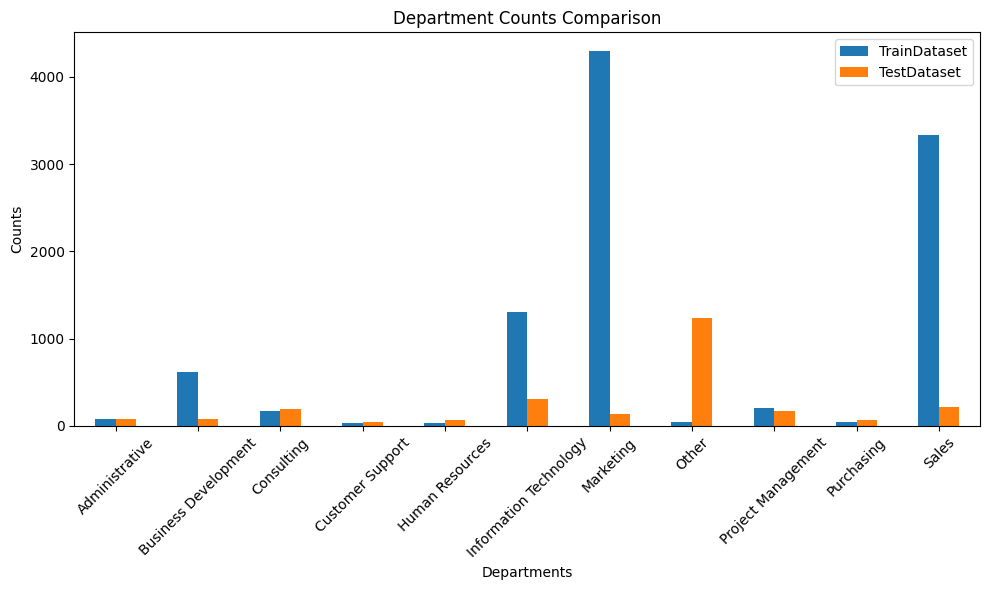

In [ ]:
# Department values counts from "department.csv"
departments = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")
counts1 = departments["label"].value_counts()
# Department values counts from linkedin CV
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
counts2 = df["department"].value_counts()

counts = pd.DataFrame(
    {
        "TrainDataset": counts1,
        "TestDataset": counts2
    }
)
counts.plot(kind = "bar", figsize = (10,6))
plt.xlabel("Departments")
plt.ylabel("Counts")
plt.title("Department Counts Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Result interpretation (Linkedin CV test file)
Accuracy = 56%

When we use only the job title to predict the department in the linkedin CV file, xlm-roberta-large-xnli reached a lower accuracy.

One of the possible reasons is that the label distribution here in the CV test data is quite different from the Department dataset.
For example, in the Department dataset,it includes around
* 40% is Marketing,
* 30% is Sales,
* 10% Information technology,
* only 0.42% is Other.

But in the linkedin CV test dataset,
* almost 50% of the data is Other department.

This Label distribution shift leads to the big difference in prediction accuracy.

Additionally, using job titles alone provides limited semantic information, further increasing ambiguity.

As a result, accuracy is not a reliable metric under these conditions, and the observed performance degradation is expected.

### Let's test the accuracy on the Linkedin CV file without "Other" department


In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
df = df[df["department"]!= "Other"]
# Predict department with a pretrained model based on position name
dpt_labels = df["department"].drop_duplicates().astype(str).tolist()
text = df["position"].tolist()
candidate_labels = dpt_labels
result = pipe(text, candidate_labels)

prediction = []
# For each position, we take the top-ranked predicted department.
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

# Evaluation
from sklearn.metrics import classification_report
true_label = df["department"].astype(str)
print(classification_report(true_label, prediction))

                        precision    recall  f1-score   support

        Administrative       0.32      0.64      0.43        84
  Business Development       0.68      0.53      0.59        78
            Consulting       0.60      0.70      0.64       195
      Customer Support       0.64      0.62      0.63        48
       Human Resources       0.49      0.94      0.64        69
Information Technology       0.73      0.65      0.69       309
             Marketing       0.76      0.46      0.57       133
    Project Management       0.77      0.75      0.76       173
            Purchasing       0.50      0.61      0.55        72
                 Sales       0.86      0.53      0.65       219

              accuracy                           0.64      1380
             macro avg       0.64      0.64      0.62      1380
          weighted avg       0.69      0.64      0.64      1380



After removing the data labeled with "Other" department, we see an  increase in the general accuracy of the zero shot prediction, leading to 64%. But compared to the 56% accuracy before the "Other" department data is removed, this is not a huge increase.

# Zero-shot prediction of seniority (seniority.csv)

In [ ]:
seniority = pd.read_csv("/content/DataScienceCapstoneProject/seniority.csv")
# Predict seniority with a pretrained model based on position name
sen_labels = seniority["label"].drop_duplicates()
text = seniority["text"].tolist()
candidate_labels = sen_labels
result = pipe(text, candidate_labels)

prediction = []
# For each position, we take the top-ranked predicted seniority.
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

# Evaluation
from sklearn.metrics import classification_report
true_label = seniority["label"].astype(str)
print(classification_report(true_label, prediction))

              precision    recall  f1-score   support

    Director       0.56      0.86      0.68       984
      Junior       0.75      0.28      0.41       409
        Lead       0.81      0.52      0.64      3546
  Management       0.04      0.11      0.06       756
      Senior       0.44      0.39      0.42      3733

    accuracy                           0.46      9428
   macro avg       0.52      0.43      0.44      9428
weighted avg       0.58      0.46      0.50      9428



# Zero-shot prediction of seniority  (Linkedin CV test file)


In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
sen_labels = df["seniority"].drop_duplicates()
text = df["position"].tolist()
candidate_labels = sen_labels
result = pipe(text, candidate_labels)

# The same zero-shot approach is applied.
# Only the label space changes from departments → seniority levels.

prediction = []
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

from sklearn.metrics import classification_report
print(classification_report(df["seniority"], prediction))

              precision    recall  f1-score   support

    Director       0.48      0.78      0.60       141
      Junior       0.84      0.54      0.66       230
        Lead       0.54      0.29      0.38       455
  Management       0.05      0.03      0.04       408
Professional       0.71      0.73      0.72      1211
      Senior       0.16      0.52      0.25       170

    accuracy                           0.52      2615
   macro avg       0.47      0.48      0.44      2615
weighted avg       0.54      0.52      0.51      2615



# Result interpretation (Seniority)
## Accuracy = 52%

Seniority terms (e.g., Junior, Lead, Manager) are:
* More subtle
* Often ambiguous in job titles

Zero-shot models struggle when label distinctions are not explicit in text.

## Zero shot prediction on seniority without "Professional" labeled data (Linkedin CV test file)

In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
df = df[df["seniority"] != "Professional"]
sen_labels = df["seniority"].drop_duplicates()
text = df["position"].tolist()
candidate_labels = sen_labels
result = pipe(text, candidate_labels)

# The same zero-shot approach is applied.
# Only the label space changes from departments → seniority levels.

prediction = []
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

from sklearn.metrics import classification_report
print(classification_report(df["seniority"], prediction))

              precision    recall  f1-score   support

    Director       0.48      0.79      0.60       141
      Junior       0.97      0.57      0.71       230
        Lead       0.67      0.38      0.49       455
  Management       0.19      0.05      0.08       408
      Senior       0.25      0.96      0.39       170

    accuracy                           0.43      1404
   macro avg       0.51      0.55      0.45      1404
weighted avg       0.51      0.43      0.41      1404



# Attempt to fine-tune the model on labeled department data

xlm-roberta-large-xnli showed acceptable overall zero-shot performance, and we attempted to:

* Fine-tune it using department dataset
* Evaluate on Linkedin CV dataset
* Expect improved task-specific accuracy

### Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Departments are converted from strings → numeric labels
# Required for supervised training
departments = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")
le = LabelEncoder()
codes = le.fit_transform(departments["label"].drop_duplicates())
dpt = le.inverse_transform(codes)
mapping = dict(zip(dpt, codes))

departments["labels"] = departments["label"].map(mapping)
train_dataset = departments.drop(columns = "label").rename(columns={"text":"position"})

# Encode "department" in evaluation dataset
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")[["position","department"]]
df["labels"] = df["department"].map(mapping)
eval_dataset = df.drop(columns = "department")

In [ ]:
eval_dataset

,position,labels
0,Prokurist,7
1,CFO,7
2,Betriebswirtin,7
3,Prokuristin,7
4,CFO,7
...,...,...
2610,Justitiar,7
2611,Geschäftsführer,7
2612,Präsidium,7
2613,Rechtsanwalt,7


### Prepare training and evaluation dataset



In [ ]:
from datasets import Dataset
train_dataset = Dataset.from_pandas(train_dataset)
eval_dataset = Dataset.from_pandas(eval_dataset)

In [ ]:
eval_dataset

Dataset({
    features: ['position', 'labels'],
    num_rows: 2615
})

In [ ]:
train_dataset

Dataset({
    features: ['position', 'labels'],
    num_rows: 10145
})

### Tokenization

In [ ]:
from transformers import AutoTokenizer

model_name = "joeddav/xlm-roberta-large-xnli"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Converts text into:input_ids, attention_mask
# max_length=106 is chosen based on job title length

def tokenize(batch):
  return tokenizer(batch["position"], truncation=True, padding = "max_length", max_length = 106)

train_dataset = train_dataset.map(tokenize, batched = True)
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

eval_dataset = train_dataset.map(tokenize, batched = True)
eval_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/10145 [00:00<?, ? examples/s]

Map:   0%|          | 0/10145 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['position', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 10145
})

### Model initialization for supervised classification

In [ ]:
 id2label = {int(k):str(v) for k,v in zip(codes, dpt)}
 label2id = {str(v):int(k) for k,v in id2label.items()}

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = len(label2id),
    id2label=id2label,
    label2id = label2id,
    ignore_mismatched_sizes = True
)

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at joeddav/xlm-roberta-large-xnli and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([11]) in the

* We redefine the classification head to predict departments
* ignore_mismatched_sizes=True forces reinitialization of the output layer
* Consequence: The original NLI classification head (entailment / neutral / contradiction) is discarded

### Training and evaluation

In [ ]:
# Train the model
from transformers import Trainer, TrainingArguments
training_args = TrainingArguments(
    "test_trainer", report_to="none")

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
  logits,labels = eval_pred
  predictions = np.argmax(logits, axis = -1)
  return metric.compute(predictions=predictions, references=labels)

In [ ]:
trainer = Trainer(
  model = model,
  args = training_args,
  train_dataset = train_dataset,
  eval_dataset = eval_dataset,
  compute_metrics = compute_metrics
)

trainer.evaluate()

{'eval_loss': 2.3762354850769043,
 'eval_model_preparation_time': 0.0689,
 'eval_accuracy': 0.12863479546574666,
 'eval_runtime': 218.3421,
 'eval_samples_per_second': 46.464,
 'eval_steps_per_second': 5.812}

## Result interpretation (after training)
## Accuracy = 13%

This is much worse than the 56% zero-shot accuracy.

### Why performance collapses after training

After traing, our model accuracy on evaluation data comes down to only 11%, compared to 56% before training. It seems that our model is broken after training.
Here are the possible reasons :

### Reason
xlm-roberta-large-xnli is not a standard classifier. It is trained for Natural Language Inference (NLI):
premise + hypothesis → {entailment, neutral, contradiction}
Zero-shot classification works because Hugging Face reformulates classification as NLI:
* Premise: The initial statement or context.
* Hypothesis: The statement being tested for truth relative to the premise.

Relationships:
1. Entailment: The premise logically implies the hypothesis (e.g., Premise: "A cat is on the mat." Hypothesis: "A feline is on a rug.").
2. Contradiction: The premise logically refutes the hypothesis (e.g., Premise: "The sun rises in the east." Hypothesis: "The sun never rises.").
3. Neutral: The hypothesis is neither confirmed nor denied by the premise.

When we fine-tuned it directly on:
*   input: job_position
*   label: department
The NLI alignment that makes zero-shot work is destroyed.


# Conclusion

* Zero-shot classification with xlm-roberta-large-xnli is: Effective
, Data-efficient, Suitable for this task.

* Fine-tuning this model directly is not appropriate.
It is not a standard classifier
Its strength lies in NLI-based zero-shot inference.

* For supervised learning, a better approach would be:
A model pretrained for sequence classification.
Or reformulating training data explicitly as NLI pairs

# Position-Department prediction with KNN

In [3]:
import pandas as pd

In [4]:
department = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")
test_df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")[["position","department"]]

## Embedding

We used the sentence transformer from TechWolf/JobBERT-v3 to embed our job positions for KNN.

* This is a sentence-transformers model specifically trained for job title matching and similarity.
* It's finetuned from sentence-transformers/paraphrase-multilingual-mpnet-base-v2 on a large dataset of job titles and their associated skills/requirements across multiple languages.

In [ ]:
! pip install sentence-transformers scikit-learn

In [5]:
# SentenceTransformer expects a Python list of strings, not a pandas Series.

X = department["text"].astype(str).tolist()
y = department["label"].astype(str).tolist()

In [6]:
# We split the "department.csv" dataset into the training data and evaluation data.
import numpy as np
from sklearn.model_selection import train_test_split

X = department["text"]
y = department['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 50, test_size = 0.2, shuffle = True
)

X_train = X_train.astype(str).tolist()
X_test = X_test.astype(str).tolist()
y_train = y_train.astype(str).tolist()
y_test = y_test.astype(str).tolist()

### Create Embeddings

In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("TechWolf/JobBERT-v3")
X_train_embedded = model.encode(
    X_train,
    show_progress_bar = True,
    normalize_embeddings = True
)
X_test_embedded = model.encode(
    X_test,
    show_progress_bar = True,
    normalize_embeddings = True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/199 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

2_Asym/6235903824_Dense/model.safetensor(…):   0%|          | 0.00/3.15M [00:00<?, ?B/s]

2_Asym/6235904160_Dense/model.safetensor(…):   0%|          | 0.00/3.15M [00:00<?, ?B/s]

Batches:   0%|          | 0/254 [00:00<?, ?it/s]

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

# Train KNN Classifier

In [8]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors = 5,
    metric = "cosine",
    weights="distance"
)

knn.fit(X_train_embedded, y_train)

KNeighborsClassifier(metric='cosine', weights='distance')

# Evaluate

In [10]:
for k in [3, 5, 7, 9, 11, 13, 15, 17, 19]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_train_embedded, y_train)
    score = knn.score(X_test_embedded, y_test)
    print(f"K={k}, Accuracy={score:.3f}")

K=3, Accuracy=0.930
K=5, Accuracy=0.928
K=7, Accuracy=0.931
K=9, Accuracy=0.932
K=11, Accuracy=0.932
K=13, Accuracy=0.931
K=15, Accuracy=0.933
K=17, Accuracy=0.931
K=19, Accuracy=0.929


In [11]:
knn = KNeighborsClassifier(
    n_neighbors = 15,
    metric = "cosine",
    weights="distance"
)
knn.fit(X_train_embedded, y_train)
from sklearn.metrics import classification_report
y_pred = knn.predict(X_test_embedded)
print(classification_report(y_pred, y_test))

                        precision    recall  f1-score   support

        Administrative       0.83      0.94      0.88        16
  Business Development       0.78      0.92      0.84        84
            Consulting       0.64      0.68      0.66        31
      Customer Support       0.14      1.00      0.25         1
       Human Resources       0.25      0.50      0.33         2
Information Technology       0.94      0.85      0.89       278
             Marketing       0.98      0.95      0.96       918
                 Other       0.67      1.00      0.80         6
    Project Management       0.45      0.72      0.55        18
            Purchasing       1.00      0.83      0.91         6
                 Sales       0.96      0.96      0.96       669

              accuracy                           0.93      2029
             macro avg       0.69      0.85      0.73      2029
          weighted avg       0.94      0.93      0.94      2029



### we have the highest accuracy when k = 15 , so we will use k = 15 in the following evalution process. On the test dataset from the "department.csv", we got an accuracy of 93.3%

In [11]:
k = 15
knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
knn.fit(X_train_embedded, y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=15)

## Measure the accuracy on the CV dataset

In [12]:
eval_df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
X_eval = eval_df["position"].astype(str).tolist()
y_eval = eval_df["department"].astype(str).tolist()

X_eval_embedded = model.encode(
    X_eval,
    show_progress_bar = True,
    normalize_embeddings = True
)


Batches:   0%|          | 0/82 [00:00<?, ?it/s]

In [13]:
from sklearn.metrics import classification_report
y_pred = knn.predict(X_eval_embedded)
print(classification_report(y_eval, y_pred))

                        precision    recall  f1-score   support

        Administrative       0.30      0.39      0.34        84
  Business Development       0.25      0.82      0.38        78
            Consulting       0.75      0.50      0.60       195
      Customer Support       0.88      0.15      0.25        48
       Human Resources       0.82      0.68      0.75        69
Information Technology       0.65      0.67      0.66       309
             Marketing       0.15      0.88      0.26       133
                 Other       0.94      0.05      0.10      1235
    Project Management       0.49      0.58      0.53       173
            Purchasing       0.76      0.74      0.75        72
                 Sales       0.31      0.89      0.46       219

              accuracy                           0.38      2615
             macro avg       0.57      0.58      0.46      2615
          weighted avg       0.72      0.38      0.33      2615



In the CV dataset, our prediction accuracy dropped to only 37%.
One of the main reasons is label disrtribution shift.
In our training data, the KNN model didn't get enough semantic training on the "Other" department, while in the test dataset half of the data is labeled as "Other".


## Measure the accuracy on the CV dataset without "Other" department

In [ ]:
eval_df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
eval_df = eval_df[eval_df["department"]!= "Other"]
X_eval = eval_df["position"].astype(str).tolist()
y_eval = eval_df["department"].astype(str).tolist()

X_eval_embedded = model.encode(
    X_eval,
    show_progress_bar = True,
    normalize_embeddings = True
)

from sklearn.metrics import classification_report
y_pred = knn.predict(X_eval_embedded)
print(classification_report(y_eval, y_pred))


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

                        precision    recall  f1-score   support

        Administrative       0.83      0.42      0.56        84
  Business Development       0.49      0.83      0.62        78
            Consulting       0.89      0.48      0.62       195
      Customer Support       1.00      0.15      0.25        48
       Human Resources       0.92      0.70      0.79        69
Information Technology       0.80      0.66      0.72       309
             Marketing       0.44      0.88      0.59       133
                 Other       0.00      0.00      0.00         0
    Project Management       0.74      0.58      0.65       173
            Purchasing       0.98      0.72      0.83        72
                 Sales       0.59      0.88      0.71       219

              accuracy                           0.66      1380
             macro avg       0.70      0.57      0.58      1380
          weighted avg       0.74      0.66      0.66      1380



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# KNN with distance threshold

In [14]:
# Fit KNN normally
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=15,
    metric="cosine",
    weights="distance"
)
knn.fit(X_train_embedded, y_train)

# Calculate the distances with the Linkedin data
eval_df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
X_eval = eval_df["position"].astype(str).tolist()
y_eval = eval_df["department"].astype(str).tolist()

# Evaluate with the linkedinCV data
X_eval_embedded = model.encode(
    X_eval,
    show_progress_bar = True,
    normalize_embeddings = True
)

distances, indices = knn.kneighbors(X_eval_embedded)
# distances: shape (n_samples, k)

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import accuracy_score
max_sim = 1- distances.min(axis = 1)
threshold = np.linspace(0.5,1.0,20)
# Calculate the smallest distance of our evalution sample to the nearest 15 training samples, to see if this evaluation sample is far from our training data.
# If the evaluation sample is too far from its nearest 15 training data neighbours,exceeding the threshold. We ditch it to "Other" department.
for t in threshold :
  is_other = max_sim < t
  y_pred = knn.predict(X_eval_embedded)
  y_pred_adj = y_pred.copy()
  y_pred_adj[is_other] = "Other"
  acc = accuracy_score(y_pred_adj, y_eval)
  print(f"Threshold ={t :.3f}, Accuracy={acc:.3f}")


Threshold =0.500, Accuracy=0.478
Threshold =0.526, Accuracy=0.504
Threshold =0.553, Accuracy=0.524
Threshold =0.579, Accuracy=0.540
Threshold =0.605, Accuracy=0.550
Threshold =0.632, Accuracy=0.564
Threshold =0.658, Accuracy=0.571
Threshold =0.684, Accuracy=0.574
Threshold =0.711, Accuracy=0.580
Threshold =0.737, Accuracy=0.590
Threshold =0.763, Accuracy=0.603
Threshold =0.789, Accuracy=0.631
Threshold =0.816, Accuracy=0.633
Threshold =0.842, Accuracy=0.628
Threshold =0.868, Accuracy=0.617
Threshold =0.895, Accuracy=0.608
Threshold =0.921, Accuracy=0.594
Threshold =0.947, Accuracy=0.581
Threshold =0.974, Accuracy=0.571
Threshold =1.000, Accuracy=0.511


In [19]:
from sklearn.metrics import accuracy_score

max_sim = 1- distances.min(axis = 1)
threshold = 0.816
is_other = max_sim < threshold
y_pred = knn.predict(X_eval_embedded)
y_pred_adj = y_pred.copy()
y_pred_adj[is_other] = "Other"

print(classification_report(y_pred_adj, y_eval))

                        precision    recall  f1-score   support

        Administrative       0.18      0.88      0.30        17
  Business Development       0.44      0.49      0.46        70
            Consulting       0.34      0.99      0.50        67
      Customer Support       0.04      0.67      0.08         3
       Human Resources       0.43      0.94      0.59        32
Information Technology       0.28      0.82      0.42       105
             Marketing       0.47      0.51      0.49       123
                 Other       0.93      0.59      0.72      1962
    Project Management       0.35      0.95      0.51        63
            Purchasing       0.32      0.85      0.46        27
                 Sales       0.56      0.84      0.67       146

              accuracy                           0.63      2615
             macro avg       0.39      0.77      0.47      2615
          weighted avg       0.80      0.63      0.67      2615



# Accuracy = 63.3%
With our distance threshold method, if the sample is too far from our training data, we dump it to the "Other" label. It gives us a highest accuracy of 63.3%, with a similarity threshold of 0.816.

# Seniority prediction with KNN

In [27]:
import pandas as pd

seniority = pd.read_csv("/content/DataScienceCapstoneProject/seniority.csv")
cv = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")

In [28]:
trainCounts = seniority["label"].value_counts()
trainCounts["Professional"] = 0
testCounts = cv["seniority"].value_counts()

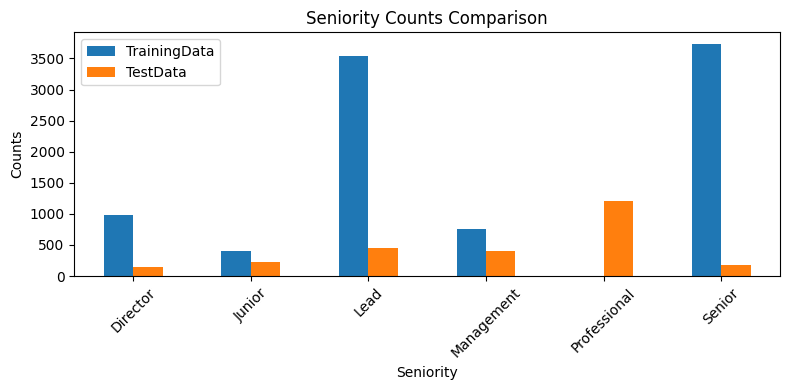

In [ ]:
import matplotlib.pyplot as plt

counts = pd.DataFrame({
    "TrainingData" : trainCounts,
    "TestData" : testCounts
})

counts.plot(kind = "bar", figsize = (8,4))
plt.xlabel("Seniority")
plt.ylabel("Counts")
plt.title("Seniority Counts Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Here we also have the similar issue of label distribution drift like we have when we predict departments.
In the training data, we have around one third of "Lead" and one third of "Senior". But in the Test data, most of the data is labeled as "Professional", which doesn't appear in the Training data.

### We split the "seniority.csv" dataset into the training data and evaluation data.

In [29]:

import numpy as np
from sklearn.model_selection import train_test_split

X = seniority["text"]
y = seniority['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 50, test_size = 0.2, shuffle = True
)

In [30]:
# SentenceTransformer expects a Python list of strings, not a pandas Series.
X_train = X_train.astype(str).tolist()
y_train = y_train.astype(str).tolist()
X_test = X_test.astype(str).tolist()
y_test = y_test.astype(str).tolist()

## Create Embeddings

In [31]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("TechWolf/JobBERT-v3")
X_train_embedded = model.encode(
    X_train,
    show_progress_bar = True,
    normalize_embeddings = True
)
X_test_embedded = model.encode(
    X_test,
    show_progress_bar = True,
    normalize_embeddings = True
)

Batches:   0%|          | 0/236 [00:00<?, ?it/s]

Batches:   0%|          | 0/59 [00:00<?, ?it/s]

## Train KNN classifier

In [33]:
from sklearn.neighbors import KNeighborsClassifier
for k in [5, 7, 9, 11, 13, 15, 17 ,19, 21,23,25,27, 29,31]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", weights = "distance")
    knn.fit(X_train_embedded, y_train)
    score = knn.score(X_test_embedded, y_test)
    print(f"K={k}, Accuracy={score:.3f}")

K=5, Accuracy=0.768
K=7, Accuracy=0.771
K=9, Accuracy=0.777
K=11, Accuracy=0.778
K=13, Accuracy=0.778
K=15, Accuracy=0.786
K=17, Accuracy=0.791
K=19, Accuracy=0.788
K=21, Accuracy=0.795
K=23, Accuracy=0.790
K=25, Accuracy=0.790
K=27, Accuracy=0.793
K=29, Accuracy=0.791
K=31, Accuracy=0.791


In [34]:
y_pred = knn.predict(X_test_embedded)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

    Director       0.56      0.81      0.66       146
      Junior       0.46      0.78      0.58        55
        Lead       0.87      0.77      0.82       802
  Management       0.67      0.64      0.65       148
      Senior       0.84      0.84      0.84       735

    accuracy                           0.79      1886
   macro avg       0.68      0.77      0.71      1886
weighted avg       0.81      0.79      0.80      1886



###  we have the highest accuracy when k = 21, so to prevent underfitting, we test a few different k values in the following evalution process. When we train on the test dataset in the "seniority.csv" dataset, we have a 79.5% accuracy rate.

## Test on CV dataset

In [35]:
# Embed the positions in CV dataset
X_eval_embedded = model.encode(
    cv["position"].astype(str).tolist(),
    show_progress_bar = True,
    normalize_embeddings = True
)


Batches:   0%|          | 0/82 [00:00<?, ?it/s]

In [36]:
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=21, metric="cosine", weights = "distance")
knn.fit(X_train_embedded, y_train)
y_eval = cv["seniority"]
score = knn.score(X_eval_embedded, y_eval)
print(f"K=21, Accuracy={score:.3f}")

K=21, Accuracy=0.337


In [37]:
y_pred = knn.predict(X_eval_embedded)
print(classification_report(y_pred, y_eval))

              precision    recall  f1-score   support

    Director       0.45      0.46      0.45       136
      Junior       0.41      0.43      0.42       219
        Lead       0.71      0.40      0.51       801
  Management       0.68      0.74      0.71       374
Professional       0.00      0.00      0.00         0
      Senior       0.74      0.12      0.20      1085

    accuracy                           0.34      2615
   macro avg       0.50      0.36      0.38      2615
weighted avg       0.68      0.34      0.40      2615



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


When k = 21, we have the highest accuracy rate on the linkedin CV seniority prediction, which is 33.7%

### KNN prediction on LInkedin CV Seniority without "Professional" labeled data

In [ ]:

cv = cv[cv["seniority"] != "Professional"]
X_eval_embedded = model.encode(
    cv["position"].astype(str).tolist(),
    show_progress_bar = True,
    normalize_embeddings = True
)

y_eval = cv["seniority"]
y_pred = knn.predict(X_eval_embedded)
print(classification_report(y_pred, y_eval))

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Director       0.43      0.48      0.45       124
      Junior       0.47      0.90      0.62       121
        Lead       0.71      0.68      0.70       473
  Management       0.71      0.83      0.76       347
      Senior       0.71      0.35      0.47       339

    accuracy                           0.64      1404
   macro avg       0.60      0.65      0.60      1404
weighted avg       0.66      0.64      0.63      1404



Without the "Professional" labeled data, which is not included in the training data, the out-of-sample accuracy of our KNN model rises to 64%

# KNN-Seniority with distance threshold

In [ ]:
# Fit KNN normally
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=21,
    metric="cosine",
    weights="distance"
)
knn.fit(X_train_embedded, y_train)

# Calculate the distances with the Linkedin data

y_eval = cv["seniority"]

X_eval_embedded = model.encode(
    cv["position"].astype(str).tolist(),
    show_progress_bar = True,
    normalize_embeddings = True
)

# Evaluate with the linkedinCV data
distances, indices = knn.kneighbors(X_eval_embedded)
# distances: shape (n_samples, k)

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

In [ ]:
from sklearn.metrics import accuracy_score
max_sim = 1- distances.min(axis = 1)
threshold = np.linspace(0.1,0.5,20)
# Calculate the smallest distance of our evalution sample to the nearest 21 training samples, to see if this evaluation sample is far from our training data.
# If the evaluation sample is too far from its nearest 21 training data neighbours,exceeding the threshold. We ditch it to Professional seniority.
for t in threshold :
  is_pro = max_sim < t
  y_pred = knn.predict(X_eval_embedded)
  y_pred_adj = y_pred.copy()
  y_pred_adj[is_pro] = "Professional"
  acc = accuracy_score(y_pred_adj, y_eval)
  print(f"Threshold ={t :.3f}, Accuracy={acc:.3f}")


Threshold =0.100, Accuracy=0.337
Threshold =0.121, Accuracy=0.337
Threshold =0.142, Accuracy=0.337
Threshold =0.163, Accuracy=0.337
Threshold =0.184, Accuracy=0.337
Threshold =0.205, Accuracy=0.337
Threshold =0.226, Accuracy=0.337
Threshold =0.247, Accuracy=0.337
Threshold =0.268, Accuracy=0.337
Threshold =0.289, Accuracy=0.337
Threshold =0.311, Accuracy=0.337
Threshold =0.332, Accuracy=0.337
Threshold =0.353, Accuracy=0.337
Threshold =0.374, Accuracy=0.335
Threshold =0.395, Accuracy=0.333
Threshold =0.416, Accuracy=0.331
Threshold =0.437, Accuracy=0.329
Threshold =0.458, Accuracy=0.327
Threshold =0.479, Accuracy=0.322
Threshold =0.500, Accuracy=0.317


With our distance threshold method, if the sample is too far from our training data, we dump it to the "Professional" label. It gives us a highest accuracy of 33.7%, which is the same as the accuracy before we apply this distance threshold methos. Distance threshold method doesn't help.

Possible reason :
Label ambiguity dominates the task.
LinkedIn titles like:
“Associate”
“Consultant”
“Staff”
“Member”
“Analyst”
are:
semantically very close,
but map to different seniority labels
So:
high cosine similarity ≠ clear label